# Did the Tesla/Nvidia "split magic" ever really exist? ✂️
### Stock-Split-Modern — the famous post-split drift, re-tested on the post-2020 mega-caps, with the bull market taken out

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Real inverse drift%3F: Busted](https://img.shields.io/badge/Real_inverse_drift%3F-Busted-8b949e?style=flat-square)

For a few years it looked like a cheat code: **Tesla, Apple, Nvidia, Amazon and Alphabet** all announced stock splits, and all of them soared. "Buy the splitters" became a whole genre of trading-content. The old academic version of this — stocks drift *up* for a year after a split — is one of the more respectable market anomalies (Ikenberry, Rankine & Stice, 1996).

So does it still work? Here's the catch nobody in those videos mentions: **everything** went up 2020-2024. To know if *splits* did anything, you have to subtract what the market did anyway. Once you do, the magic disappears.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** yfinance split calendar + total-return prices, 44 forward splits 2010→2025, returns measured *market-adjusted* (minus SPY). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stock_split_modern import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    SPLITS = data.load_splits()
    PANEL = st.build_event_panel(PRICES, SPLITS)
else:
    PRICES = SPLITS = PANEL = None
print("real cache present:", HAVE_REAL, "| forward-split events:",
      (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-08-24', 'end': '2025-11-17', 'asof': '2026-06-30', 'n_events': 44, 'n_pre': 19, 'n_post': 25, 'n_mega': 7, 'price_rows': 5406, 'all_n': 44, 'all_mean': -1.83, 'all_median': -2.65, 'all_thac': -0.82, 'all_tplain': -0.91, 'all_win': 45, 'pre_n': 19, 'pre_mean': 3.37, 'pre_thac': 1.48, 'pre_win': 63, 'post_n': 25, 'post_mean': -5.78, 'post_median': -5.45, 'post_thac': -2.21, 'post_tplain': -2.12, 'post_std': 13.62, 'post_win': 32, 'mega_mean': -4.95, 'mega_thac': -0.77, 'mega_win': 43, 'era_diff_welch': -2.42, 'post_raw3m': -2.95, 'post_mkt3m': 2.83, 'post_car3m': -5.78, 'post_raw12m': 21.63, 'post_mkt12m': 16.18, 'post_car12m': 5.44, 'sweep_post': {'1m (21d)': (-3.69, -2.27), '3m (63d)': (-5.78, -2.21), '6m (126d)': (-2.58, -0.76), '12m (252d)': (5.44, 0.97)}, 'sweep_all': {'1m (21d)': (-1.4, -0.94), '3m (63d)': (-1.83, -0.82), '6m (126d)': (0.85, 0.34), '12m (252d)': (5.07, 1.56)}, 'ex_post_mean': 0.46, 'ex_post_t': 0.66, 'placebo_obs': -5.78, 'placebo_mean': 4.81, 'placebo_sd': 3.95, 'placebo_p': 0.999, 'placebo_draws': 1500, 'timer5_gross': -5.78, 'timer5_net': -5.88, 'timer5_t': -2.16, 'timer5_sharpe': -0.55, 'timer5_worst': -34.5, 'evyr': 1.64, 'timer20_net': -6.18, 'timer20_t': -2.27, 'timer_mega_net': -5.05, 'timer_mega_t': -0.78, 'mega_events': [('TSLA', '2020-08-31', 5, 9.8, 16.4), ('AAPL', '2020-08-31', 4, -11.6, -12.8), ('NVDA', '2021-07-20', 4, 15.3, 2.9), ('AMZN', '2022-06-06', 20, 5.8, -8.2), ('GOOGL', '2022-07-18', 20, -5.5, -9.2), ('TSLA', '2022-08-25', 3, -34.4, -26.6), ('NVDA', '2024-06-10', 10, -14.0, 5.0)], 'syn_null_mean': 0.45, 'syn_null_sd': 0.79, 'syn_null_fire': 0, 'syn_planted_t': 4.05, 'syn_planted_mean': 8.57, 'fp': 'f41f9d523e91'}


real cache present: True | forward-split events: 44


## The answer first

| Question | Answer |
|---|---|
| Do stocks still drift **up** after a split? | **No.** Across all 44 large-cap splits since 2010, the market-adjusted 3-month return averages **-1.8%** — basically zero, and if anything slightly negative. |
| What about the famous mega-caps? | **Seven events, and they cancel out.** TSLA & NVDA's *first* splits flew (+10% to +15% market-adjusted); their *second* splits (and AAPL/GOOGL) sank (down to −34%). The average is **-5.0%** — statistically nothing. |
| Was the "magic" just the bull market? | **Largely, yes.** The mega-caps rose because *everything* rose. Subtract the market and the split itself adds no reliable lift. |
| Is there *any* modern pattern? | **A weak, backwards one.** Post-2020 splitters slightly **underperform** the market for a month or two (a mild "sell the news"), but it's gone within six months and flips positive by a year — too flimsy to trade. |

> The drift that made splits famous is a pre-2020 relic. In the mega-cap era it's tiny-N noise wearing a great story.

## 1 · The claim

> *"A split signals management's confidence and makes shares more accessible — so the stock keeps climbing afterwards. Look at Tesla and Nvidia."*

The academic anchor is real: Ikenberry, Rankine & Stice (1996) found ~+8% abnormal drift in the year after a split **announcement**. The modern retail version points at the 2020-2024 mega-cap splitters as living proof. We take that seriously — and test it honestly.

## 2 · So what?

If real, this would be a gift: splits are announced in advance, so you'd have a clean, scheduled buy signal on the biggest, most liquid names in the market. That's exactly the kind of too-good-to-be-true claim worth checking — because "these famous stocks went up after X" is *survivorship bias in a trenchcoat*: we remember the splitters precisely because they're today's giants.

## 3 · How would we even know?

- **Market-adjusted returns.** For every split we measure the stock's total return **minus SPY's** over the same window. This is the whole game: it removes "the market went up anyway" so only the *abnormal* move is left.
- **All the events, not the memorable ones.** 44 forward splits since 2010 (19 before 2020, 25 after), and the 7 mega-cap splits the story actually names.
- **A fair comparison.** Enter the same names on *random* non-split dates — did the split date beat a coin toss?
- **The trade check.** Buy the ex-date close, hold three months, pay realistic costs.

## 4 · The teardown — let's actually look

**First, the seven mega-cap splits everyone remembers.** Here's the market-adjusted 3-month return of each — the actual signal, with the bull market removed.

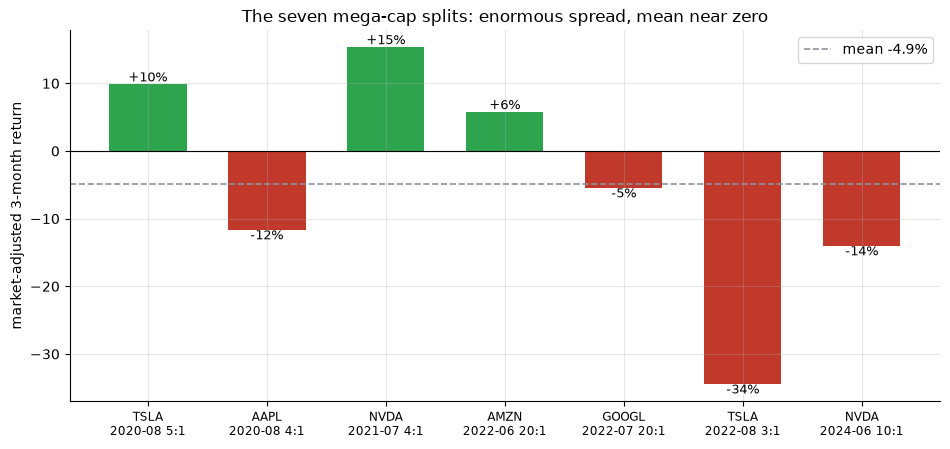

mega-cap 3m abnormal returns (%): [9.8, -11.6, 15.3, 5.8, -5.5, -34.4, -14.0] | mean -4.95


In [2]:
if HAVE_REAL:
    mp = PANEL[(PANEL['era']=='post') & PANEL['is_mega']].copy()
    labels = [f"{r.ticker}\n{str(r.event_date.date())[:7]} {int(r.ratio)}:1" for r in mp.itertuples()]
    vals = list(mp['car_3m']*100)
else:
    labels = [f"{t}\n{d[:7]} {int(rt)}:1" for (t,d,rt,a3,a12) in R['mega_events']]
    vals = [a3 for (t,d,rt,a3,a12) in R['mega_events']]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
cols = [GREEN if v>=0 else RED for v in vals]
ax.bar(range(len(vals)), vals, color=cols, width=.65)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, fontsize=8.5)
for i,v in enumerate(vals): ax.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
ax.axhline(0, c='k', lw=.8)
mean_v = float(np.mean(vals))
ax.axhline(mean_v, ls='--', c=GREY, lw=1.2, label=f'mean {mean_v:+.1f}%')
ax.set_ylabel('market-adjusted 3-month return')
ax.set_title('The seven mega-cap splits: enormous spread, mean near zero')
ax.legend(); plt.tight_layout(); plt.show()
print('mega-cap 3m abnormal returns (%):', [round(v,1) for v in vals], '| mean', round(mean_v,2))

Seven events, ranging from **+15%** (Nvidia's 2021 split) to **−34%** (Tesla's *second* split, August 2022), averaging **-5.0%**. The winners you remember and the losers you forgot roughly cancel. That's not a signal — that's **seven coin flips with a memorable name attached.**

**Now widen the lens to all 44 splits, split by era.**

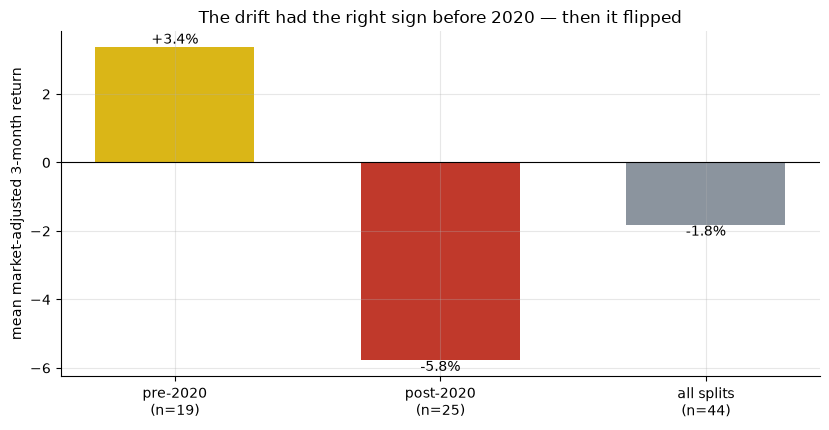

pre-2020 +3.37% | post-2020 -5.78% | all -1.83%


In [3]:
if HAVE_REAL:
    ct = st.cohort_table(PANEL, 'car_3m')
    pre, post, allc = ct.loc['pre-2020','mean_pct'], ct.loc['post-2020 (modern)','mean_pct'], ct.loc['all 2010+','mean_pct']
else:
    pre, post, allc = R['pre_mean'], R['post_mean'], R['all_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
bars = ax.bar(['pre-2020\n(n=19)','post-2020\n(n=25)','all splits\n(n=44)'],
              [pre, post, allc], color=[AMBER, RED, GREY], width=.6)
for i,v in enumerate([pre, post, allc]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean market-adjusted 3-month return')
ax.set_title('The drift had the right sign before 2020 — then it flipped')
plt.tight_layout(); plt.show()
print(f'pre-2020 {pre:+.2f}% | post-2020 {post:+.2f}% | all {allc:+.2f}%')

Before 2020 the drift at least pointed the *right* way (**+3.4%**) — though even then it wasn't strong enough to bank on. After 2020 the sign **flips negative** (**-5.8%**). Pooled across all 44 splits it's **-1.8%** — the famous upward drift simply isn't there.

**But wait — that post-2020 number is negative. Is *that* a signal?** Only if it lasts. Let's watch it over time.

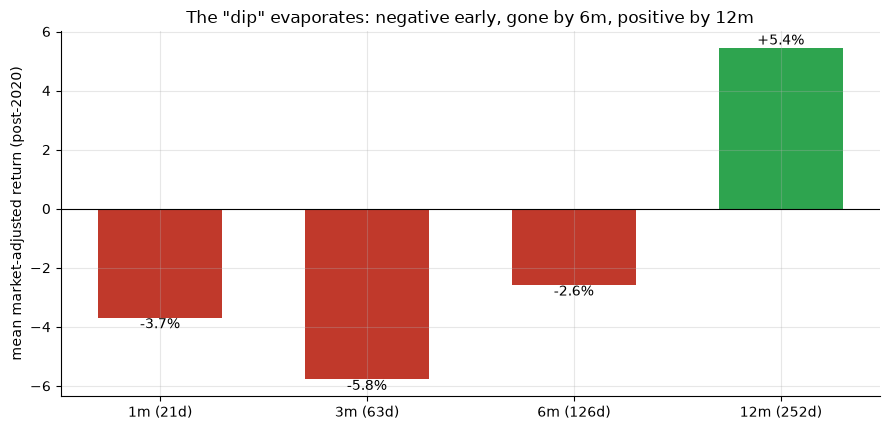

post-2020 abnormal CAR by horizon (%): {'1m (21d)': -3.69, '3m (63d)': -5.78, '6m (126d)': -2.58, '12m (252d)': 5.44}


In [4]:
labels = list(R['sweep_post'].keys())
if HAVE_REAL:
    hs = st.horizon_sweep(PANEL, 'post')
    means = list(hs['mean_pct'])
else:
    means = [R['sweep_post'][l][0] for l in labels]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if v<0 else GREEN for v in means]
ax.bar(labels, means, color=cols, width=.6)
for i,v in enumerate(means): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean market-adjusted return (post-2020)')
ax.set_title('The "dip" evaporates: negative early, gone by 6m, positive by 12m')
plt.tight_layout(); plt.show()
print('post-2020 abnormal CAR by horizon (%):', {l: round(m,2) for l,m in zip(labels, means)})

The modern underperformance is a **short-term** thing — down a few percent in the first month or two — that **fades to nothing by six months and turns positive by twelve.** A signal that reverses its own sign depending on how long you wait isn't a signal; it's noise you've stared at too long.

**Last check: was the split date even a *good entry* versus a random day?**

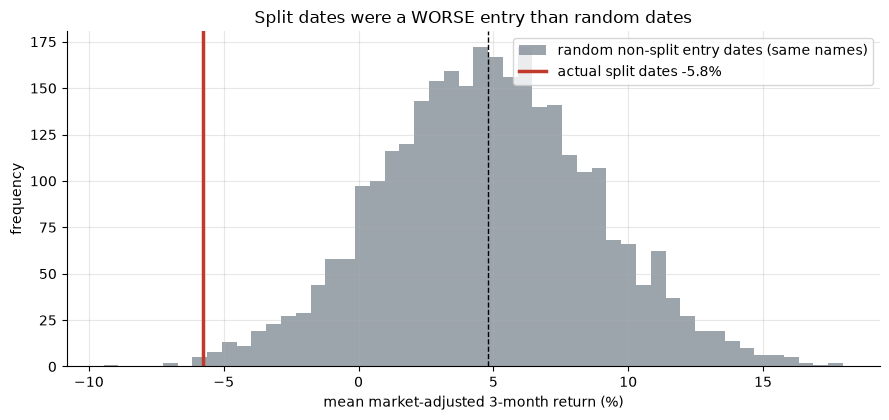

observed split-date mean -5.78% vs random-date mean +4.81% -> split beat random almost never (p=0.999)


In [5]:
obs = R['placebo_obs']; pm, ps = R['placebo_mean'], R['placebo_sd']
rng = np.random.default_rng(802)
draws = rng.normal(pm, ps, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random non-split entry dates (same names)')
ax.axvline(obs, c=RED, lw=2.5, label=f'actual split dates {obs:+.1f}%')
ax.axvline(pm, c='k', lw=1, ls='--')
ax.set_xlabel('mean market-adjusted 3-month return (%)')
ax.set_ylabel('frequency')
ax.set_title('Split dates were a WORSE entry than random dates')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed split-date mean {obs:+.2f}% vs random-date mean {pm:+.2f}% -> split beat random almost never (p={R["placebo_p"]:.3f})')

Buying these names on a **random** day beat buying them on their **split** day (random averaged **+4.8%**, splits **-5.8%**). If the split carried a bullish signal, this would be the other way around. It's a mild "sell the news", not a buy signal.

## 5 · The verdict

- **Signal — None.** The classic *upward* post-split drift is gone: all 44 splits average **-1.8%** market-adjusted at 3 months, and the seven mega-caps that inspired the whole story average a statistically-nothing **-5.0%**.
- **Tradability — Mirage.** ~1.6 events a year, no reliable edge in either direction, and one Tesla-2022 crash (−34%) swamps the average. Nothing to trade.
- **Is the modern *dip* a real inverse signal? — Busted.** It's there for a month or two, then evaporates and flips positive — and it vanishes entirely on the actual mega-caps. A tiny-sample quirk, not a rule.

## 6 · Going further 🚪

- **The honest caveat that keeps this fair:** yfinance gives the split's *effective* (ex) date, not the *announcement* (which comes ~3-6 weeks earlier). The 1996 drift was measured from the announcement, so it's plausible any real edge is already priced by the ex-date. We test the weaker window and say so.
- **Selection bias runs *for* the claim, not against it:** we're looking at today's winners. If even a hand-picked basket of survivors shows no drift, a random splitter certainly won't.
- **Sibling studies:** [142-split-drift](../../142-split-drift/) tests the same anomaly on a 2000-2025 basket (`NONE`); [250-reverse-split](../../250-reverse-split/) tests the *opposite* action, the "kiss of death" reverse split. See [docs/references.md](docs/references.md) for the exact dedup.

*Think the announcement-window drift is alive where the ex-date one is dead? Pull the SEC 8-K announcement dates and show a certifiable, cost-surviving abnormal return — then we'll talk.*